**Paso 1: Configuración del entorno**



In [1]:
!pip install numpy pandas matplotlib scipy

**Paso 2: Cargar y visualizar datos EEG simulados**


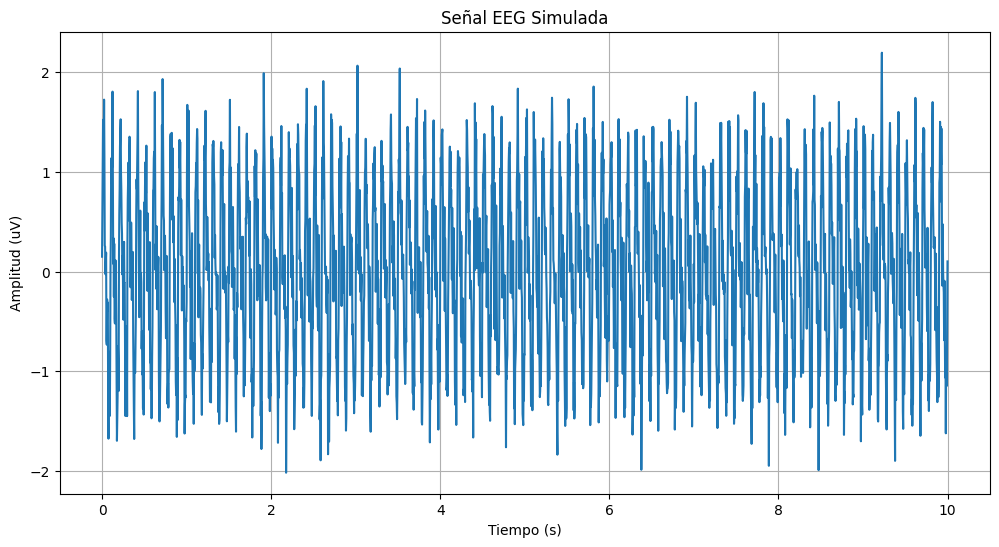

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# Configuración
fs = 250  # Frecuencia de muestreo (Hz)
duration = 10  # Duración en segundos
n_samples = fs * duration
time = np.linspace(0, duration, n_samples)

# Crear señales EEG simuladas (mezcla de diferentes frecuencias)
np.random.seed(42)
eeg_signal = (np.sin(2 * np.pi * 10 * time) +  # Componente Alpha (10 Hz)
             0.5 * np.sin(2 * np.pi * 20 * time) +  # Componente Beta (20 Hz)
             0.2 * np.sin(2 * np.pi * 50 * time) +  # Ruido alta frecuencia
             0.3 * np.random.normal(size=len(time)))  # Ruido aleatorio

# Crear un DataFrame similar a los datos reales
df = pd.DataFrame({
    'timestamp': time,
    'channel_1': eeg_signal,
    'attention': np.random.random(len(time))  # Simular métrica de atención
})

# Visualizar la señal cruda
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['channel_1'])
plt.title('Señal EEG Simulada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.grid()
plt.show()

**Paso 3: Aplicar filtro pasa banda para aislar frecuencias Alpha (8-12 Hz)**

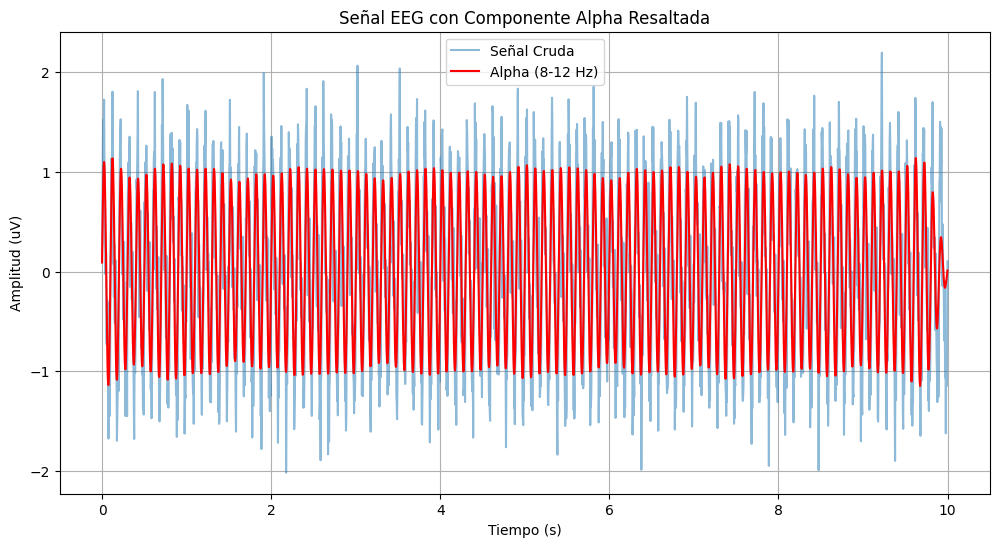

In [3]:
# Diseñar filtro pasa banda para Alpha (8-12 Hz)
nyquist = 0.5 * fs
low = 8 / nyquist
high = 12 / nyquist
b, a = signal.butter(4, [low, high], btype='band')

# Aplicar filtro
df['alpha_filtered'] = signal.filtfilt(b, a, df['channel_1'])

# Visualizar señal filtrada
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['channel_1'], label='Señal Cruda', alpha=0.5)
plt.plot(df['timestamp'], df['alpha_filtered'], label='Alpha (8-12 Hz)', color='red')
plt.title('Señal EEG con Componente Alpha Resaltada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.legend()
plt.grid()
plt.show()

**Paso 4: Calcular potencia en banda Alpha y definir umbral de atención**

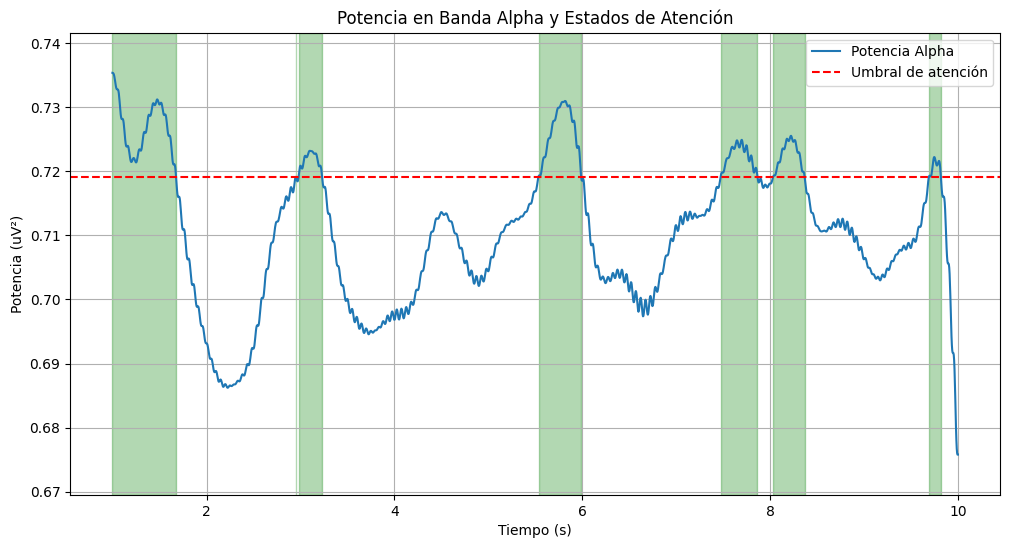

In [4]:
# Calcular potencia en banda Alpha (RMS)
window_size = 1 * fs  # Ventana de 1 segundo
df['alpha_power'] = (df['alpha_filtered'].rolling(window=window_size)
                       .apply(lambda x: np.sqrt(np.mean(x**2))))

# Definir umbral de atención (percentil 75 como ejemplo)
threshold = np.percentile(df['alpha_power'].dropna(), 75)
df['attention_state'] = df['alpha_power'] > threshold

# Visualizar potencia y umbral
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['alpha_power'], label='Potencia Alpha')
plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral de atención')
plt.fill_between(df['timestamp'], 0, 1, where=df['attention_state'],
                 color='green', alpha=0.3, transform=plt.gca().get_xaxis_transform())
plt.title('Potencia en Banda Alpha y Estados de Atención')
plt.xlabel('Tiempo (s)')
plt.ylabel('Potencia (uV²)')
plt.legend()
plt.grid()
plt.show()

**Paso 5: Simular una acción visual básica (usando matplotlib)**

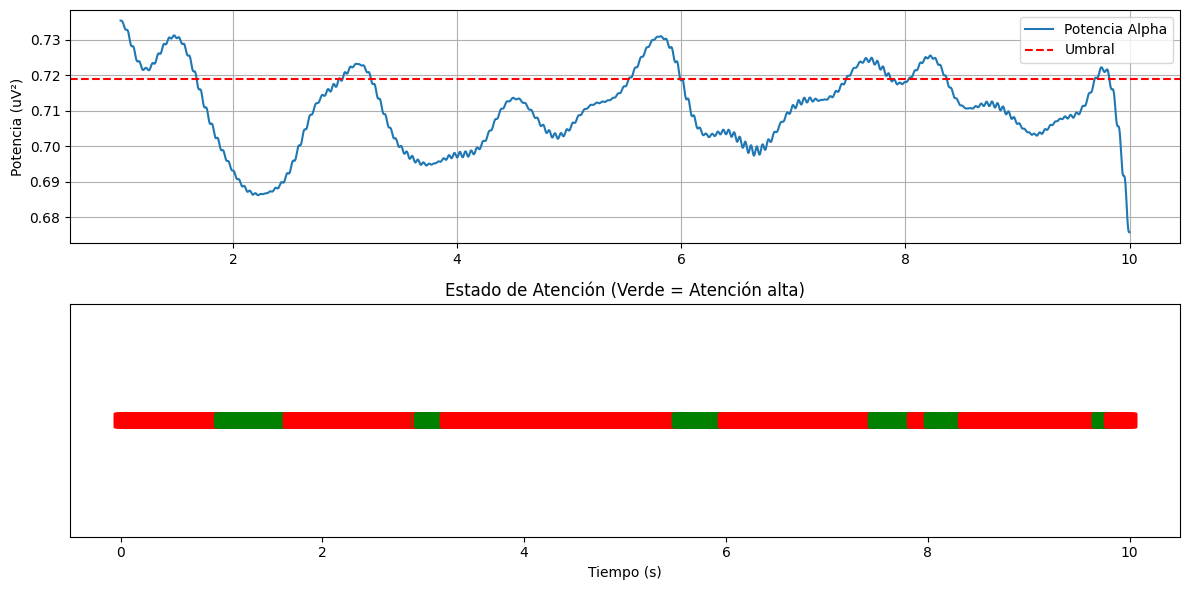

In [7]:
# Simulación de respuesta visual
plt.figure(figsize=(12, 6))

# Gráfico de la señal
plt.subplot(2, 1, 1)
plt.plot(df['timestamp'], df['alpha_power'], label='Potencia Alpha')
plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral')
plt.ylabel('Potencia (uV²)')
plt.legend()
plt.grid()

# Gráfico de estado de atención (visual)
plt.subplot(2, 1, 2)
plt.scatter(df['timestamp'], [1]*len(df),
            c=df['attention_state'].map({True: 'green', False: 'red'}),
            s=100, marker='s')
plt.yticks([])
plt.xlabel('Tiempo (s)')
plt.title('Estado de Atención (Verde = Atención alta)')
plt.tight_layout()
plt.show()